# Implement a protocol

> Give an object the right methods and it satisfies raptor's contracts —
> whether or not it has ever heard of raptor.

**Time:** ~5 min · **Runs on:** CPU, no GPU needed · **You need:**
[What the contracts buy you](01_what_the_contracts_buy_you)

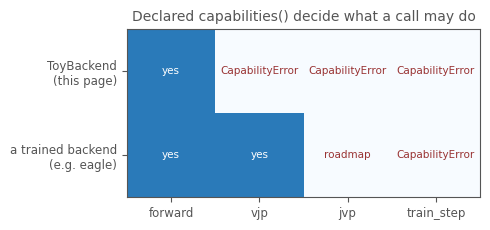

In [1]:
import sys; sys.path.insert(0, "../_shared")
from nb_diagrams import capability_grid
capability_grid()


## The code

An `Executable` is a compiled, callable program: it declares `forward`,
**`vjp`** (reverse-mode: given a cotangent — a weighting of the output —
produces the matching weighting of the input), **`jvp`** (forward-mode:
given a tangent — a direction in the input — produces the matching
direction in the output), and `parameters`. Below, `ToyExecutable`
implements that shape by hand:

In [2]:
from raptor.protocols import CapabilityError, Executable

class ToyExecutable:
    def __init__(self, fn): self._fn = fn
    def forward(self, inputs): return self._fn(inputs)
    def vjp(self, cotangents): raise CapabilityError("no vjp")
    def jvp(self, tangents): raise CapabilityError("no jvp")
    def parameters(self): return []

print("Executable?", isinstance(ToyExecutable(lambda x: x), Executable))


Executable? True


What `vjp`/`jvp` actually compute does not matter below — only that calling
one `ToyBackend` has not declared will raise `CapabilityError` (a dedicated
exception, explained below), not guess.

A `Backend` builds one of those: `capabilities()` is its own declaration of
what it supports:


In [3]:
from raptor.protocols import Backend

class ToyBackend:
    name = "toy"
    def capabilities(self): return frozenset({"forward"})
    def compile(self, program): return ToyExecutable(program)

print("Backend?", isinstance(ToyBackend(), Backend))


Backend? True


Both checks pass by shape alone — "duck typing": judged by which methods exist, never by which class an object inherits from.


Now use them together: compile a program, call the one capability
`ToyBackend` declared, then call the one it did not — which raises
**`CapabilityError`** (a dedicated exception: this object cannot do that,
by declaration) rather than returning a silent wrong answer:

In [4]:
backend = ToyBackend()
executable = backend.compile(lambda x: x * 2)
print("forward(21) =", executable.forward(21))
try:
    executable.vjp(None)
except CapabilityError as exc:
    print("caught:", exc)


forward(21) = 42
caught: no vjp


`forward` runs; the undeclared `vjp` raises instead of returning a silent wrong answer.


## The kernel-provider protocol

`ManifestProvider` is satisfied by anything with a matching
`build(directory)` method — it duck-types hawk's own `Bundle`, the object
that writes a kernel's manifest, without either side importing the other:


In [5]:
from raptor.protocols import ManifestProvider

class ToyBundle:
    def build(self, directory):
        """Pretend to emit a manifest; return its path."""
        return f"{directory}/manifest.json"

print("ManifestProvider?", isinstance(ToyBundle(), ManifestProvider))
print("A plain object is not:", isinstance(object(), ManifestProvider))


ManifestProvider? True
A plain object is not: False


A plain `object()` fails the check; `ToyBundle` passes it on the strength of its one method alone.


## What just happened

- `capabilities()` is a declaration a backend makes about itself; calling a
  capability it never declared raises `CapabilityError` rather than
  returning a silent wrong answer.
- `ManifestProvider` is satisfied the same structural way as
  `Backend`/`Executable` — by shape, checked with `isinstance`, never by
  inheritance.
- None of the toy objects above import hawk or eagle, yet each one is
  exactly what a real engine checks for before it will run a kernel.

## Try this

Add `"vjp"` to `ToyBackend.capabilities()` without adding a real `vjp` method
to `ToyExecutable` — `isinstance(executable, Executable)` still reports
`True` (the protocol only checks that the method *exists*, not that the
declared capability set agrees with it); the mismatch only shows up when you
actually call it.

## Next

[Read the interop matrix](04_plug_into_the_interop_matrix)
reads the family's own certification declaration. Deeper:
[Concepts](/content/concepts).

## Going deeper (optional)

`Marshal` mirrors eagle's own per-role input coercion — the shape a
launcher (the code that actually calls a compiled kernel) needs once it
must bind real arguments: state vectors, per-sample scalars, uniform
constants, lookup tables. `ToyMarshal` below is the minimal object
satisfying all seven methods, each returning an empty/default value:

In [6]:
from raptor.protocols import Marshal

class ToyMarshal:
    def coerce_vec_inputs(self, *a, **kw): return ({}, 1)
    def coerce_mat_inputs(self, *a, **kw): return {}
    def coerce_per_sample(self, *a, **kw): return {}
    def coerce_uniforms(self, *a, **kw): return {}
    def coerce_tables(self, *a, **kw): return {}
    def coerce_terminated(self, *a, **kw): return None
    def require_n(self, n, **kw): return n

print("Marshal?", isinstance(ToyMarshal(), Marshal))

Marshal? True


`True` — none of the seven methods above do real work, but all seven exist, and that is all the protocol asks.